<a href="https://colab.research.google.com/github/arnavpatil427gh/RetailScope/blob/main/notebooks/retailscope_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_excel('/content/Online Retail.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


In [ ]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print("Missing count:")
print(df.isnull().sum(), end="\n\n")
print("Missing percentage:")
print((df.isnull().sum()/df.shape[0])*100)

Missing count:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing percentage:
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]
display(
    duplicate_rows
    .sort_values(["InvoiceNo", "StockCode", "InvoiceDate"]).head(20)
)
print("\nExact duplicate rows:", df.duplicated().sum())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom



Exact duplicate rows: 5268


In [ ]:
print(df[["Quantity", "UnitPrice"]].describe())

            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


In [ ]:
print("Zero or negative quantities:", (df["Quantity"] <= 0).sum())
print("Zero or negative unit prices:", (df["UnitPrice"] <= 0).sum())

Zero or negative quantities: 10624
Zero or negative unit prices: 2517


In [ ]:
print("Negative quantities:", (df["Quantity"] < 0).sum() )
print("Zero quantities:", (df["Quantity"] == 0).sum() )
print("Positive quantities:", (df["Quantity"] > 0).sum() )

Negative quantities: 10624
Zero quantities: 0
Positive quantities: 531285


In [ ]:
negative_qty = df[df["Quantity"] < 0]

display(
    negative_qty[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "CustomerID"
        ]
    ].head(15)
)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0


In [ ]:
nonpositive_prices = df[df["UnitPrice"] <= 0]
print("Rows with non-positive proces:", len(nonpositive_prices), end="\n\n")

display(
    nonpositive_prices[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "CustomerID"
        ]
    ].head(20)
)

Rows with non-positive proces: 2517



,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN
1988,536550,85044,NaN,1,0.0,NaN
2024,536552,20950,NaN,1,0.0,NaN
2025,536553,37461,NaN,3,0.0,NaN
2026,536554,84670,NaN,23,0.0,NaN
2406,536589,21777,NaN,-10,0.0,NaN


In [ ]:
zero_price = df[df["UnitPrice"] == 0]

display(
    zero_price.groupby(
        ["StockCode", "Description"],
        dropna=False
    ).size()
    .sort_values(ascending=False)
    .head(15)
)

,,0
StockCode,Description,
23084,NaN,10
35965,NaN,10
22084,NaN,9
22676,FRENCH BLUE METAL DOOR SIGN 1,9
22683,FRENCH BLUE METAL DOOR SIGN 8,8
22679,FRENCH BLUE METAL DOOR SIGN 4,7
22686,FRENCH BLUE METAL DOOR SIGN No,7
21116,OWL DOORSTOP,7
22666,RECIPE BOX PANTRY YELLOW DESIGN,7


In [ ]:
invoice_text = df["InvoiceNo"].astype("string").str.strip()

is_cancelled = invoice_text.str.upper().str.startswith(
    "C", na=False
)

is_negative_qty = df["Quantity"] < 0

print("Cancellation invoice rows:", is_cancelled.sum())
print("Negative quantity rows:", is_negative_qty.sum())

print(
    "Rows with both cancellation invoice and negative quantity:",
    (is_cancelled & is_negative_qty).sum()
)

print(
    "Negative quantity rows without cancellation invoice:",
    (~is_cancelled & is_negative_qty).sum()
)

Cancellation invoice rows: 9288
Negative quantity rows: 10624
Rows with both cancellation invoice and negative quantity: 9288
Negative quantity rows without cancellation invoice: 1336


In [ ]:
invoice_text = df["InvoiceNo"].astype("string").str.strip()
is_cancelled = invoice_text.str.upper().str.startswith("C", na=False)

print("Rows with cancellation Invoice IDs:", is_cancelled.sum())
print("Distinct cancellation invoives:", invoice_text[is_cancelled].nunique())

Rows with cancellation Invoice IDs: 9288
Distinct cancellation invoives: 3836


In [ ]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"], errors="coerce"
)

print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())
print("Invalid dates:", df["InvoiceDate"].isna().sum())

Earliest transaction: 2010-12-01 08:26:00
Latest transaction: 2011-12-09 12:50:00
Invalid dates: 0


Separate zero and negative prices

In [ ]:
print("Zero prices:", (df["UnitPrice"] == 0).sum())
print("Negative prices:", (df["UnitPrice"] < 0).sum())

# Inspect records with zero or negative prices
price_issues = df.loc[
    df["UnitPrice"] <= 0,
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]
]

display(price_issues.head(15))

Zero prices: 2515
Negative prices: 2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


Negative quantities with cancellation IDs

In [ ]:
invoice_text = df["InvoiceNo"].astype("string").str.strip()

is_cancelled = invoice_text.str.upper().str.startswith(
    "C", na=False
)

other_negative_qty = df[
    (df["Quantity"] < 0) & (~is_cancelled)
]

print("Negative quantities without C invoice:",
      len(other_negative_qty))

display(
    other_negative_qty[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "CustomerID",
            "Country"
        ]
    ].head(20)
)

Negative quantities without C invoice: 1336


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


Whether duplicates affect sales total

In [ ]:
# Calculate line value before removing duplicates
df["LineValue"] = df["Quantity"] * df["UnitPrice"]

duplicate_mask = df.duplicated(keep="first")

print("Duplicate rows:", duplicate_mask.sum())

print(
    "Line value of duplicate rows:",
    df.loc[duplicate_mask, "LineValue"].sum()
)

Duplicate rows: 5268
Line value of duplicate rows: 21740.98


Cleaning the dataset

In [ ]:
# Create a working copy and remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

# Calculate signed line value (not profit)
df_clean["LineValue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

# Standardize invoice text for reliable classification
invoice_text = df_clean["InvoiceNo"].astype("string").str.strip()

# Create diagnostic flags
df_clean["IsCancellationInvoice"] = (
    invoice_text.str.upper().str.startswith("C", na=False)
)

df_clean["IsNegativeQuantity"] = df_clean["Quantity"] < 0
df_clean["IsZeroPrice"] = df_clean["UnitPrice"] == 0
df_clean["IsNegativePrice"] = df_clean["UnitPrice"] < 0
df_clean["HasMissingCustomerID"] = df_clean["CustomerID"].isna()

# Review the cleaned dataset
print("\nMissing values after duplicate removal:")
print(df_clean.isna().sum())

print("\nTransaction flags:")
print("Cancellation invoice rows:",
      df_clean["IsCancellationInvoice"].sum())
print("Negative quantity rows:",
      df_clean["IsNegativeQuantity"].sum())
print("Zero-price rows:", df_clean["IsZeroPrice"].sum())
print("Negative-price rows:", df_clean["IsNegativePrice"].sum())

display(df_clean.head())

Original rows: 541909
Rows after removing duplicates: 536641
Rows removed: 5268

Missing values after duplicate removal:
InvoiceNo                     0
StockCode                     0
Description                1454
Quantity                      0
InvoiceDate                   0
UnitPrice                     0
CustomerID               135037
Country                       0
LineValue                     0
IsCancellationInvoice         0
IsNegativeQuantity            0
IsZeroPrice                   0
IsNegativePrice               0
HasMissingCustomerID          0
dtype: int64

Transaction flags:
Cancellation invoice rows: 9251
Negative quantity rows: 10587
Zero-price rows: 2510
Negative-price rows: 2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineValue,IsCancellationInvoice,IsNegativeQuantity,IsZeroPrice,IsNegativePrice,HasMissingCustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,False,False,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False,False,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,False,False,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False,False,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,False,False,False,False


Creating separate dataset for sales analysis

In [ ]:
sales_df = df_clean[
    (~df_clean["IsCancellationInvoice"])
    & (df_clean["Quantity"] > 0)
    & (df_clean["UnitPrice"] > 0)
].copy()

print("Rows available for positive-sales analysis:", len(sales_df))
print("Total sales value:", round(sales_df["LineValue"].sum(), 2))
print("Unique invoices:", sales_df["InvoiceNo"].nunique())
print("Unique products:", sales_df["StockCode"].nunique())
print("Unique customers:", sales_df["CustomerID"].nunique())

Rows available for positive-sales analysis: 524878
Total sales value: 10642110.8
Unique invoices: 19960
Unique products: 3922
Unique customers: 4338


Remaining unusual transactions

In [ ]:
# Inspect negative-price rows
display(
    df_clean.loc[
        df_clean["IsNegativePrice"],
        ["InvoiceNo", "StockCode", "Description",
         "Quantity", "UnitPrice", "CustomerID", "Country"]
    ]
)

# Inspect a sample of zero-price rows
display(
    df_clean.loc[
        df_clean["IsZeroPrice"],
        ["InvoiceNo", "StockCode", "Description",
         "Quantity", "InvoiceDate", "CustomerID", "Country"]
    ].head(20)
)

# Inspect negative quantities without cancellation-style invoice numbers
display(
    df_clean.loc[
        df_clean["IsNegativeQuantity"]
        & (~df_clean["IsCancellationInvoice"]),
        ["InvoiceNo", "StockCode", "Description",
         "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]
    ].head(20)
)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN


# Exploratory Data Analytics

In [ ]:
import matplotlib.pyplot as plt

# Work on a copy of the sales dataset
sales_df = sales_df.copy()

# Extract month for trend analysis
sales_df["YearMonth"] = (
    sales_df["InvoiceDate"].dt.to_period("M").astype(str)
)

# Use StockCode when product descriptions are missing
sales_df["ProductName"] = (
    sales_df["Description"]
    .fillna(sales_df["StockCode"].astype(str))
)

print("Date range:",
      sales_df["InvoiceDate"].min(),
      "to",
      sales_df["InvoiceDate"].max())

print("Total sales value:",
      round(sales_df["LineValue"].sum(), 2))

print("Missing customer IDs:",
      sales_df["CustomerID"].isna().sum())

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total sales value: 10642110.8
Missing customer IDs: 132186


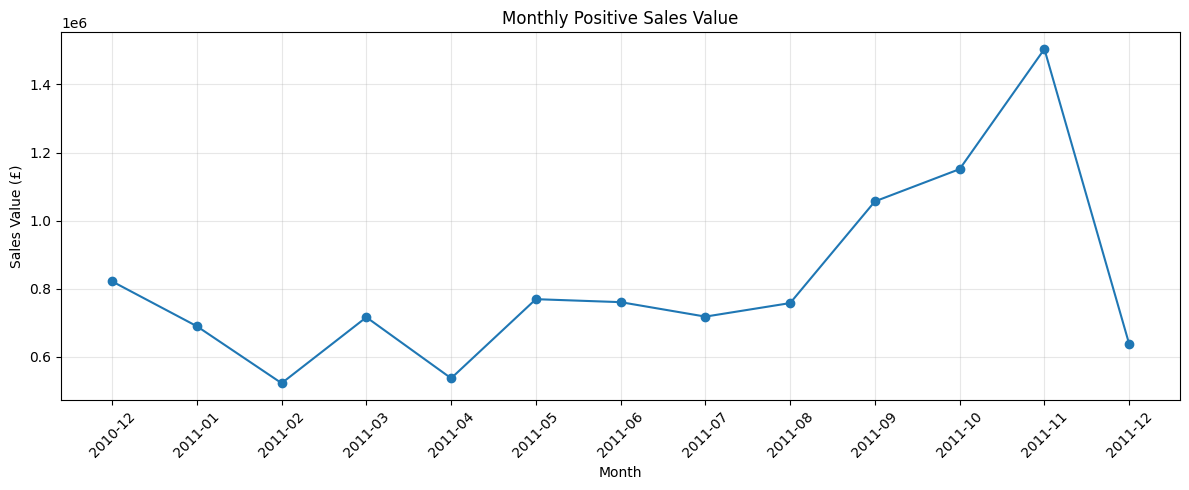

,SalesValue
YearMonth,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [ ]:
monthly_sales = (
    sales_df.groupby("YearMonth")["LineValue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Positive Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales Value (£)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(monthly_sales.to_frame("SalesValue"))

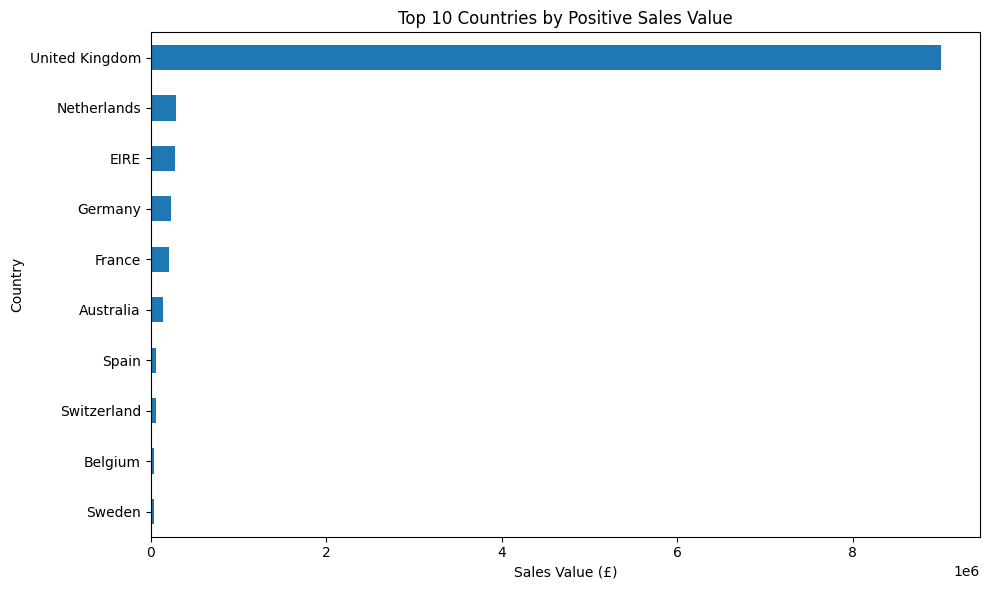

,SalesValue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [ ]:
country_sales = (
    sales_df.groupby("Country")["LineValue"]
    .sum()
    .sort_values(ascending=False)
)

top_countries = country_sales.head(10)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Positive Sales Value")
plt.xlabel("Sales Value (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

display(top_countries.to_frame("SalesValue"))

In [ ]:
customer_sales = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        TotalSales=("LineValue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueInvoices=("InvoiceNo", "nunique")
    )
    .sort_values("TotalSales", ascending=False)
)

print("Customers analyzed:", len(customer_sales))

display(customer_sales.head(10))

Customers analyzed: 4338


,TotalSales,TotalQuantity,UniqueInvoices
CustomerID,,,
14646.0,280206.02,196915,73
18102.0,259657.30,64124,60
17450.0,194390.79,69973,46
16446.0,168472.50,80997,2
14911.0,143711.17,80240,201
12415.0,124914.53,77374,21
14156.0,117210.08,57768,55
17511.0,91062.38,64549,31
16029.0,80850.84,40108,63


Calculate the key business metrics

In [ ]:
# 1. Country contribution to total positive sales
country_sales = (
    sales_df.groupby("Country")["LineValue"]
    .sum()
    .sort_values(ascending=False)
)

total_sales = sales_df["LineValue"].sum()

country_summary = pd.DataFrame({
    "SalesValue": country_sales,
    "SalesSharePct": country_sales / total_sales * 100
})

print("Top 5 countries by sales:")
display(country_summary.head(5).round(2))

print(
    "UK share of positive sales:",
    round(country_summary.loc["United Kingdom", "SalesSharePct"], 2),
    "%"
)

# 2. Monthly sales summary
monthly_sales = (
    sales_df.groupby("YearMonth")["LineValue"]
    .sum()
    .sort_index()
)

print("Highest-sales month:", monthly_sales.idxmax(),
      "£", round(monthly_sales.max(), 2))

print("Lowest-sales month:", monthly_sales.idxmin(),
      "£", round(monthly_sales.min(), 2))

print("\nComplete monthly sales:")
display(monthly_sales.to_frame("SalesValue").round(2))

Top 5 countries by sales:


,SalesValue,SalesSharePct
Country,,
United Kingdom,9001744.09,84.59
Netherlands,285446.34,2.68
EIRE,283140.52,2.66
Germany,228678.40,2.15
France,209625.37,1.97


UK share of positive sales: 84.59 %
Highest-sales month: 2011-11 £ 1503866.78
Lowest-sales month: 2011-02 £ 522545.56

Complete monthly sales:


,SalesValue
YearMonth,
2010-12,821452.73
2011-01,689811.61
2011-02,522545.56
2011-03,716215.26
2011-04,536968.49
2011-05,769296.61
2011-06,760547.01
2011-07,718076.12
2011-08,757841.38


In [ ]:
# Top products by positive sales value
top_products = (
    sales_df.groupby("ProductName")
    .agg(
        SalesValue=("LineValue", "sum"),
        QuantitySold=("Quantity", "sum"),
        InvoiceCount=("InvoiceNo", "nunique")
    )
    .sort_values("SalesValue", ascending=False)
)

print("Top 10 products by sales value:")
display(top_products.head(10).round(2))

print("Top 10 products by quantity sold:")
display(
    top_products.sort_values(
        "QuantitySold", ascending=False
    ).head(10).round(2)
)

Top 10 products by sales value:


,SalesValue,QuantitySold,InvoiceCount
ProductName,,,
DOTCOM POSTAGE,206248.77,706,706
REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2256
PARTY BUNTING,99445.23,18283,1685
JUMBO BAG RED RETROSPOT,94159.81,48371,2089
MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
POSTAGE,78101.88,3150,1126
Manual,77752.82,6985,290


Top 10 products by quantity sold:


,SalesValue,QuantitySold,InvoiceCount
ProductName,,,
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
WORLD WAR 2 GLIDERS ASSTD DESIGNS,13814.01,54951,535
JUMBO BAG RED RETROSPOT,94159.81,48371,2089
WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2256
POPCORN HOLDER,34288.67,36749,803
PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,1320
ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
RABBIT NIGHT LIGHT,66870.03,30739,994


In [ ]:
customer_sales = customer_sales.copy()

customer_sales.index = (
    customer_sales.index.astype("Int64")
)

customer_sales.index.name = "CustomerID"

display(customer_sales.head(10).round(2))

,TotalSales,TotalQuantity,UniqueInvoices
CustomerID,,,
14646,280206.02,196915,73
18102,259657.30,64124,60
17450,194390.79,69973,46
16446,168472.50,80997,2
14911,143711.17,80240,201
12415,124914.53,77374,21
14156,117210.08,57768,55
17511,91062.38,64549,31
16029,80850.84,40108,63


Unusual transactions before RFM

In [ ]:
# Inspect the unusual product and high-value customers
product_to_check = "PAPER CRAFT , LITTLE BIRDIE"
customers_to_check = [16446, 12346, 14646]

print("PAPER CRAFT transactions:")
display(
    df_clean.loc[
        df_clean["Description"].eq(product_to_check),
        ["InvoiceNo", "StockCode", "Description", "Quantity",
         "InvoiceDate", "UnitPrice", "CustomerID"]
    ].sort_values("InvoiceDate")
)

print("Transactions for selected customers:")
display(
    df_clean.loc[
        df_clean["CustomerID"].isin(customers_to_check),
        ["InvoiceNo", "StockCode", "Description", "Quantity",
         "InvoiceDate", "UnitPrice", "CustomerID"]
    ].sort_values(["CustomerID", "InvoiceDate"])
)

PAPER CRAFT transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0


Transactions for selected customers:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0
37952,539491,21981,PACK OF 12 WOODLAND TISSUES,12,2010-12-20 10:09:00,0.29,14646.0
37953,539491,21986,PACK OF 12 PINK POLKADOT TISSUES,12,2010-12-20 10:09:00,0.29,14646.0
37954,539491,22720,SET OF 3 CAKE TINS PANTRY DESIGN,2,2010-12-20 10:09:00,4.95,14646.0
...,...,...,...,...,...,...,...
537783,581338,23344,JUMBO BAG 50'S CHRISTMAS,140,2011-12-08 12:12:00,1.79,14646.0
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0


In [ ]:
# Use the deduplicated data
rfm_data = df_clean.copy()

# Exclude rows with non-positive prices from monetary calculations
# while preserving valid positive and negative quantities
rfm_data = rfm_data[rfm_data["UnitPrice"] > 0].copy()

# Identify invoice cancellations
invoice_text = rfm_data["InvoiceNo"].astype("string").str.strip()

rfm_data["IsCancellationInvoice"] = (
    invoice_text.str.upper().str.startswith("C", na=False)
)

# Signed monetary value: positive sales minus recorded negative values
rfm_data["LineValue"] = (
    rfm_data["Quantity"] * rfm_data["UnitPrice"]
)

# Exclude transactions without customer IDs for customer-level RFM
customer_data = rfm_data.dropna(subset=["CustomerID"]).copy()

# Recency and Frequency use positive purchase activity
purchases = customer_data[
    (customer_data["Quantity"] > 0)
    & (~customer_data["IsCancellationInvoice"])
].copy()

# Reference date: one day after the latest date in the dataset
reference_date = df_clean["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

# Calculate Recency and Frequency
rfm = purchases.groupby("CustomerID").agg(
    LastPurchaseDate=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique")
)

rfm["Recency"] = (
    reference_date - rfm["LastPurchaseDate"].dt.normalize()
).dt.days

# Calculate Monetary from all signed transactions for each customer
monetary = customer_data.groupby("CustomerID")["LineValue"].sum()

rfm["Monetary"] = monetary

# Display highest net monetary customers
rfm = rfm.sort_values("Monetary", ascending=False)
rfm.index = rfm.index.astype("Int64")
rfm.index.name = "CustomerID"

print("Reference date:", reference_date.date())
print("Customers in RFM:", len(rfm))

display(rfm.head(10).round(2))

Reference date: 2011-12-10
Customers in RFM: 4338


,LastPurchaseDate,Frequency,Recency,Monetary
CustomerID,,,,
14646,2011-12-08 12:12:00,73,2,279489.02
18102,2011-12-09 11:50:00,60,1,256438.49
17450,2011-12-01 13:29:00,46,9,187322.17
14911,2011-12-08 15:54:00,201,2,132458.73
12415,2011-11-15 14:22:00,21,25,123725.45
14156,2011-11-30 10:54:00,55,10,113214.59
17511,2011-12-07 10:12:00,31,3,88125.38
16684,2011-12-05 14:06:00,28,5,65892.08
13694,2011-12-06 09:32:00,50,4,62690.54


In [ ]:
display(
    rfm.loc[
        rfm.index.isin([12346, 16446, 14646]),
        ["LastPurchaseDate", "Recency", "Frequency", "Monetary"]
    ].sort_values("Monetary", ascending=False)
)

,LastPurchaseDate,Recency,Frequency,Monetary
CustomerID,,,,
14646,2011-12-08 12:12:00,2,73,279489.02
16446,2011-12-09 09:15:00,1,2,2.90
12346,2011-01-18 10:01:00,326,1,0.00


RFM scores 1 to 5

In [ ]:
rfm_scored = rfm.copy()

# Percentile-based scores, handling ties safely
# Lower recency is better, so reverse its score
rfm_scored["R_Score"] = (
    6 - np.ceil(rfm_scored["Recency"].rank(method="average", pct=True) * 5)
).astype(int)

rfm_scored["F_Score"] = (
    np.ceil(rfm_scored["Frequency"].rank(method="average", pct=True) * 5)
).astype(int)

rfm_scored["M_Score"] = (
    np.ceil(rfm_scored["Monetary"].rank(method="average", pct=True) * 5)
).astype(int)

rfm_scored["RFM_Score"] = (
    rfm_scored["R_Score"].astype(str)
    + rfm_scored["F_Score"].astype(str)
    + rfm_scored["M_Score"].astype(str)
)

display(
    rfm_scored.sort_values(
        ["R_Score", "F_Score", "M_Score"],
        ascending=False
    ).head(10).round(2)
)

,LastPurchaseDate,Frequency,Recency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,
14646,2011-12-08 12:12:00,73,2,279489.02,5,5,5,555
18102,2011-12-09 11:50:00,60,1,256438.49,5,5,5,555
17450,2011-12-01 13:29:00,46,9,187322.17,5,5,5,555
14911,2011-12-08 15:54:00,201,2,132458.73,5,5,5,555
14156,2011-11-30 10:54:00,55,10,113214.59,5,5,5,555
17511,2011-12-07 10:12:00,31,3,88125.38,5,5,5,555
16684,2011-12-05 14:06:00,28,5,65892.08,5,5,5,555
13694,2011-12-06 09:32:00,50,4,62690.54,5,5,5,555
15311,2011-12-09 12:00:00,91,1,59284.19,5,5,5,555


Create customer segments

In [ ]:
conditions = [
    # High-value, frequent, recent customers
    (
        (rfm_scored["R_Score"] >= 4)
        & (rfm_scored["F_Score"] >= 4)
        & (rfm_scored["M_Score"] >= 4)
    ),

    # Previously frequent and valuable, but not recently active
    (
        (rfm_scored["R_Score"] <= 2)
        & (rfm_scored["F_Score"] >= 4)
        & (rfm_scored["M_Score"] >= 4)
    ),

    # Frequent purchasers
    (
        (rfm_scored["F_Score"] >= 4)
        & (rfm_scored["R_Score"] >= 3)
    ),

    # Potential to become loyal
    (
        (rfm_scored["R_Score"] >= 4)
        & (rfm_scored["F_Score"] >= 2)
    ),

    # Recently active, but only one invoice
    (
        (rfm_scored["R_Score"] >= 4)
        & (rfm_scored["F_Score"] == 1)
    ),

    # Infrequent and not recently active
    (
        (rfm_scored["R_Score"] <= 2)
        & (rfm_scored["F_Score"] <= 2)
    )
]

labels = [
    "Champions",
    "Cannot Lose Them",
    "Loyal Customers",
    "Potential Loyalists",
    "Recent Customers",
    "Hibernating"
]

rfm_scored["Segment"] = np.select(
    conditions,
    labels,
    default="Needs Attention"
)

display(
    rfm_scored[
        ["Recency", "Frequency", "Monetary",
         "R_Score", "F_Score", "M_Score",
         "RFM_Score", "Segment"]
    ].head(10).round(2)
)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
14646,2,73,279489.02,5,5,5,555,Champions
18102,1,60,256438.49,5,5,5,555,Champions
17450,9,46,187322.17,5,5,5,555,Champions
14911,2,201,132458.73,5,5,5,555,Champions
12415,25,21,123725.45,4,5,5,455,Champions
14156,10,55,113214.59,5,5,5,555,Champions
17511,3,31,88125.38,5,5,5,555,Champions
16684,5,28,65892.08,5,5,5,555,Champions
13694,4,50,62690.54,5,5,5,555,Champions


Summarize the arguments

In [ ]:
segment_summary = (
    rfm_scored.groupby("Segment")
    .agg(
        CustomerCount=("Recency", "size"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageMonetary=("Monetary", "mean"),
        TotalMonetary=("Monetary", "sum")
    )
    .sort_values("CustomerCount", ascending=False)
)

segment_summary["CustomerSharePct"] = (
    segment_summary["CustomerCount"]
    / segment_summary["CustomerCount"].sum()
    * 100
)

display(segment_summary.round(2))

,CustomerCount,AverageRecency,AverageFrequency,AverageMonetary,TotalMonetary,CustomerSharePct
Segment,,,,,,
Needs Attention,1220,108.30,2.15,708.03,863795.62,28.12
Hibernating,962,222.85,1.00,345.46,332337.29,22.18
Champions,912,12.87,11.50,6037.77,5506449.42,21.02
Potential Loyalists,484,16.93,2.42,839.51,406320.90,11.16
Loyal Customers,380,39.52,5.79,2013.49,765126.50,8.76
Recent Customers,236,19.42,1.00,319.41,75379.98,5.44
Cannot Lose Them,144,122.57,5.93,2357.78,339520.95,3.32


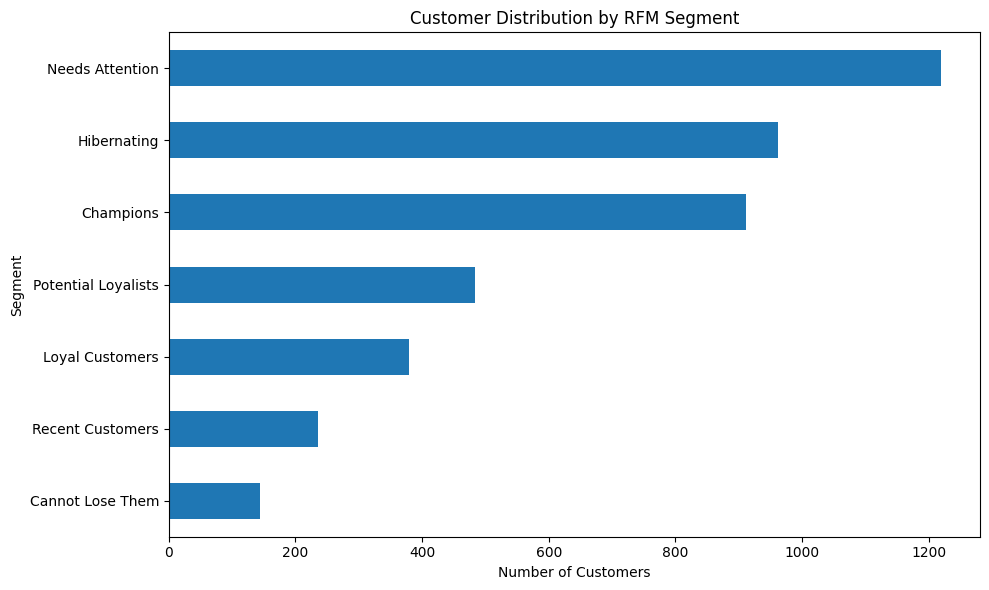

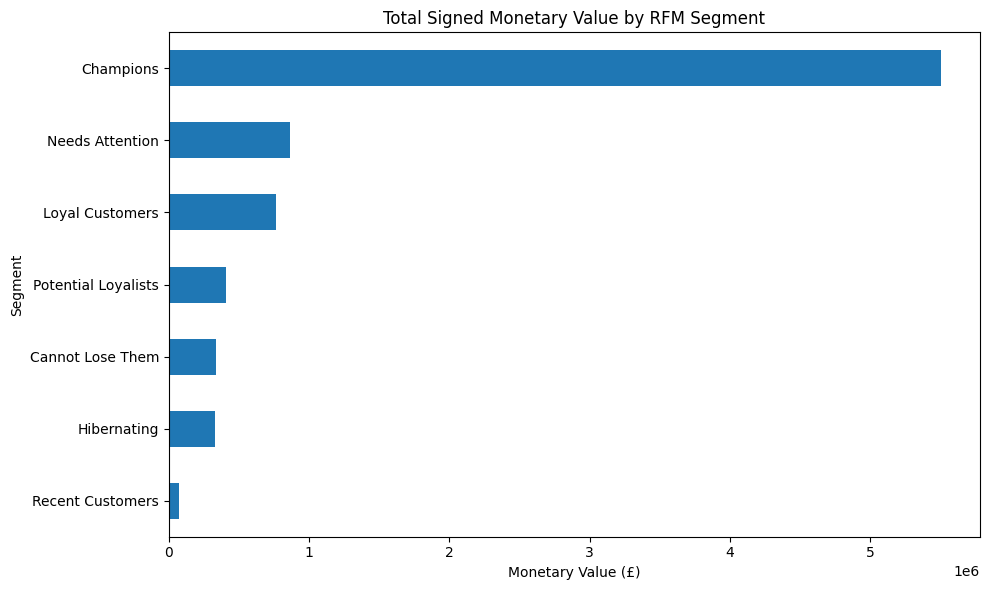

In [ ]:
# Sort segments by customer count
plot_counts = segment_summary["CustomerCount"].sort_values()

plt.figure(figsize=(10, 6))
plot_counts.plot(kind="barh")
plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

# Sort segments by total monetary value
plot_monetary = segment_summary["TotalMonetary"].sort_values()

plt.figure(figsize=(10, 6))
plot_monetary.plot(kind="barh")
plt.title("Total Signed Monetary Value by RFM Segment")
plt.xlabel("Monetary Value (£)")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

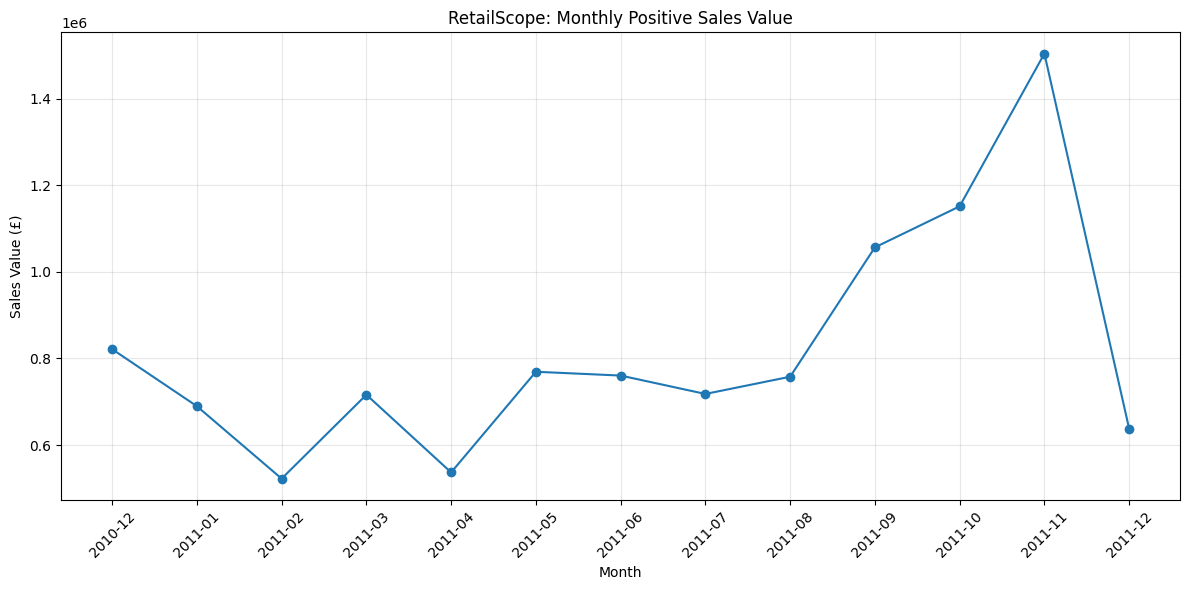

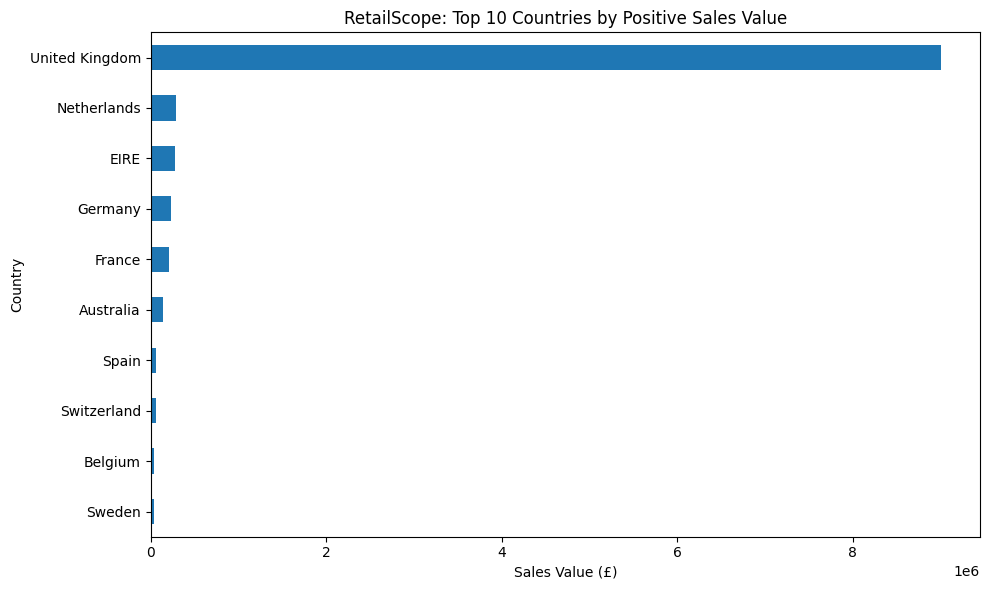

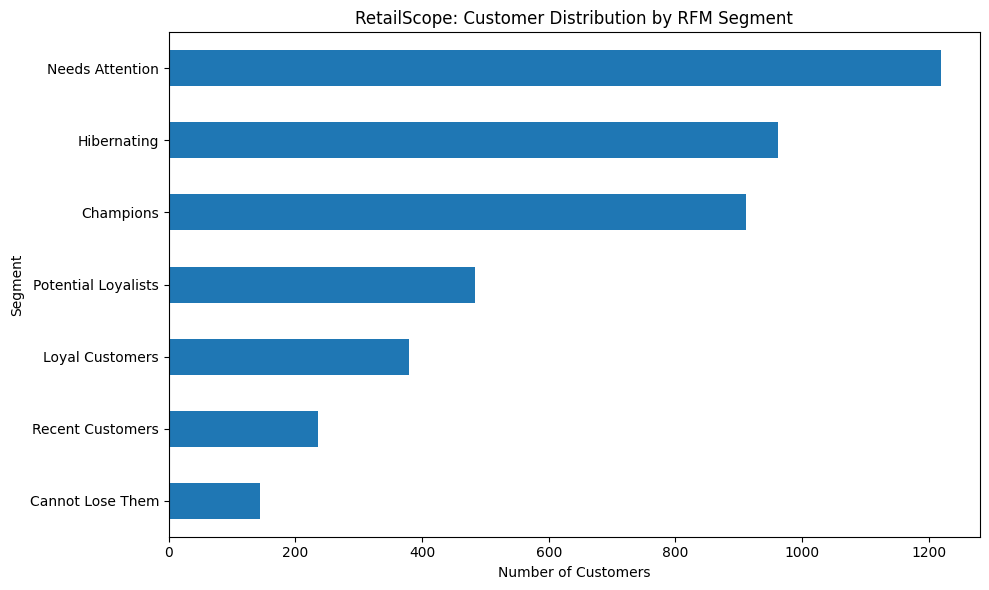

Saved charts:
['rfm_segments.png', 'top_countries.png', 'monthly_sales.png']


In [ ]:
import os
os.makedirs("reports", exist_ok=True)

# Chart 1: Monthly sales trend
monthly_sales = (
    sales_df.groupby("YearMonth")["LineValue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("RetailScope: Monthly Positive Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales Value (£)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 2: Top 10 countries
country_sales = (
    sales_df.groupby("Country")["LineValue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
country_sales.sort_values().plot(kind="barh")
plt.title("RetailScope: Top 10 Countries by Positive Sales Value")
plt.xlabel("Sales Value (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("reports/top_countries.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 3: Customer segment distribution
segment_counts = (
    rfm_scored["Segment"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="barh")
plt.title("RetailScope: Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig("reports/rfm_segments.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved charts:")
print(os.listdir("reports"))

In [ ]:
import pandas as pd

audit_df = df_clean.copy()

# Normalize invoice numbers
audit_df["InvoiceKey"] = (
    audit_df["InvoiceNo"]
    .astype("string")
    .str.strip()
    .str.upper()
)

audit_df["IsCancellation"] = audit_df["InvoiceKey"].str.startswith(
    "C", na=False
)

# For cancellation invoice IDs, remove the leading C
audit_df["BaseInvoiceKey"] = audit_df["InvoiceKey"].str.replace(
    r"^C", "", regex=True
)

# Find original invoices that have a corresponding cancellation invoice
cancelled_invoice_keys = set(
    audit_df.loc[audit_df["IsCancellation"], "BaseInvoiceKey"]
)

audit_df["HasCancellationInvoice"] = (
    audit_df["BaseInvoiceKey"].isin(cancelled_invoice_keys)
)

print("Cancellation invoice rows:", audit_df["IsCancellation"].sum())
print(
    "Original invoice rows linked to a cancellation invoice:",
    (
        (~audit_df["IsCancellation"])
        & audit_df["HasCancellationInvoice"]
    ).sum()
)

Cancellation invoice rows: 9251
Original invoice rows linked to a cancellation invoice: 0


In [ ]:
# Keep positive purchases with positive prices
# and exclude original invoices linked to cancellation invoices
valid_purchases = audit_df[
    (~audit_df["IsCancellation"])
    & (~audit_df["HasCancellationInvoice"])
    & (audit_df["Quantity"] > 0)
    & (audit_df["UnitPrice"] > 0)
    & (audit_df["CustomerID"].notna())
].copy()

reference_date = (
    audit_df["InvoiceDate"].max().normalize()
    + pd.Timedelta(days=1)
)

rfm_validated = valid_purchases.groupby("CustomerID").agg(
    LastPurchaseDate=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Quantity", lambda x: 0)  # placeholder; replaced below
)

# Monetary is positive sales value for the retained invoices
rfm_validated["Monetary"] = (
    valid_purchases.assign(
        LineValue=valid_purchases["Quantity"] * valid_purchases["UnitPrice"]
    )
    .groupby("CustomerID")["LineValue"]
    .sum()
)

rfm_validated["Recency"] = (
    reference_date - rfm_validated["LastPurchaseDate"].dt.normalize()
).dt.days

rfm_validated.index = rfm_validated.index.astype("Int64")
rfm_validated.index.name = "CustomerID"

print("Customers in revised RFM:", len(rfm_validated))
display(
    rfm_validated.sort_values("Monetary", ascending=False)
    .head(10)
    .round(2)
)

Customers in revised RFM: 4338


,LastPurchaseDate,Frequency,Monetary,Recency
CustomerID,,,,
14646,2011-12-08 12:12:00,73,280206.02,2
18102,2011-12-09 11:50:00,60,259657.30,1
17450,2011-12-01 13:29:00,46,194390.79,9
16446,2011-12-09 09:15:00,2,168472.50,1
14911,2011-12-08 15:54:00,201,143711.17,2
12415,2011-11-15 14:22:00,21,124914.53,25
14156,2011-11-30 10:54:00,55,117210.08,10
17511,2011-12-07 10:12:00,31,91062.38,3
16029,2011-11-01 10:27:00,63,80850.84,39


In [ ]:
customer_ids = [12346, 16446, 14646, 18102]

print("Previous RFM:")
display(
    rfm.loc[
        rfm.index.isin(customer_ids),
        ["Recency", "Frequency", "Monetary"]
    ]
)

print("Cancellation-adjusted RFM:")
display(
    rfm_validated.loc[
        rfm_validated.index.isin(customer_ids),
        ["Recency", "Frequency", "Monetary"]
    ]
)

Previous RFM:


,Recency,Frequency,Monetary
CustomerID,,,
14646,2,73,279489.02
18102,1,60,256438.49
16446,1,2,2.90
12346,326,1,0.00


Cancellation-adjusted RFM:


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
14646,2,73,280206.02
16446,1,2,168472.50
18102,1,60,259657.30


Verify cancellation pairs

In [ ]:
import pandas as pd

audit = df_clean.copy()

audit["InvoiceText"] = (
    audit["InvoiceNo"].astype("string").str.strip()
)

positive = audit[
    (audit["Quantity"] > 0) &
    (audit["UnitPrice"] > 0) &
    (~audit["InvoiceText"].str.upper().str.startswith("C", na=False))
].copy()

negative = audit[
    (audit["Quantity"] < 0) &
    (audit["UnitPrice"] > 0)
].copy()

# Create matching keys
keys = ["CustomerID", "StockCode", "UnitPrice"]

positive["MatchQuantity"] = positive["Quantity"]
negative["MatchQuantity"] = negative["Quantity"].abs()

# Check the known unusual customers first
customers_to_check = [12346, 16446]

for customer in customers_to_check:
    pos = positive[positive["CustomerID"] == customer]
    neg = negative[negative["CustomerID"] == customer]

    candidates = pos.merge(
        neg,
        on=keys + ["MatchQuantity"],
        suffixes=("_original", "_negative")
    )

    candidates["TimeDifference"] = (
        candidates["InvoiceDate_negative"]
        - candidates["InvoiceDate_original"]
    )

    matches = candidates[
        (candidates["TimeDifference"] >= pd.Timedelta(0)) &
        (candidates["TimeDifference"] <= pd.Timedelta(days=7))
    ]

    print(f"\nCustomer {customer}:")
    if matches.empty:
        print("No matching transaction pair found.")
    else:
        display(matches[[
            "InvoiceNo_original",
            "InvoiceNo_negative",
            "StockCode",
            "MatchQuantity",
            "UnitPrice",
            "InvoiceDate_original",
            "InvoiceDate_negative",
            "TimeDifference"
        ]])


Customer 12346:


,InvoiceNo_original,InvoiceNo_negative,StockCode,MatchQuantity,UnitPrice,InvoiceDate_original,InvoiceDate_negative,TimeDifference
0,541431,C541433,23166,74215,1.04,2011-01-18 10:01:00,2011-01-18 10:17:00,0 days 00:16:00



Customer 16446:


,InvoiceNo_original,InvoiceNo_negative,StockCode,MatchQuantity,UnitPrice,InvoiceDate_original,InvoiceDate_negative,TimeDifference
0,581483,C581484,23843,80995,2.08,2011-12-09 09:15:00,2011-12-09 09:27:00,0 days 00:12:00


In [ ]:

# Validate the two confirmed cancellation pairs
confirmed_pairs = [
    {
        "CustomerID": 12346,
        "OriginalInvoice": "541431",
        "CancellationInvoice": "C541433",
        "Quantity": 74215,
        "UnitPrice": 1.04
    },
    {
        "CustomerID": 16446,
        "OriginalInvoice": "581483",
        "CancellationInvoice": "C581484",
        "Quantity": 80995,
        "UnitPrice": 2.08
    }
]

for pair in confirmed_pairs:
    original_value = pair["Quantity"] * pair["UnitPrice"]

    print(f"\nCustomer: {pair['CustomerID']}")
    print(f"Original invoice: {pair['OriginalInvoice']}")
    print(f"Cancellation invoice: {pair['CancellationInvoice']}")
    print(f"Cancelled value: £{original_value:,.2f}")



Customer: 12346
Original invoice: 541431
Cancellation invoice: C541433
Cancelled value: £77,183.60

Customer: 16446
Original invoice: 581483
Cancellation invoice: C581484
Cancelled value: £168,469.60


In [ ]:

# Copy the positive-purchase data used for RFM
purchases_validated = purchases.copy()

# Remove only the two confirmed fully cancelled original invoice lines
confirmed_cancelled_lines = [
    ("12346", "541431", "23166", 74215, 1.04),
    ("16446", "581483", "23843", 80995, 2.08)
]

# Normalize identifiers for consistent matching
purchases_validated["CustomerID_match"] = (
    purchases_validated["CustomerID"].astype(str).str.replace(r"\.0$", "", regex=True)
)
purchases_validated["InvoiceNo_match"] = (
    purchases_validated["InvoiceNo"].astype(str).str.strip()
)
purchases_validated["StockCode_match"] = (
    purchases_validated["StockCode"].astype(str).str.strip()
)

for customer, invoice, stock, qty, price in confirmed_cancelled_lines:
    mask = (
        (purchases_validated["CustomerID_match"] == customer)
        & (purchases_validated["InvoiceNo_match"] == invoice)
        & (purchases_validated["StockCode_match"] == stock)
        & (purchases_validated["Quantity"] == qty)
        & (purchases_validated["UnitPrice"] == price)
    )

    print(f"Customer {customer}: matching rows = {mask.sum()}")
    purchases_validated = purchases_validated.loc[~mask].copy()

# Recalculate monetary value from retained positive purchases
monetary_validated = purchases_validated.groupby("CustomerID")["LineValue"].sum()

comparison = pd.DataFrame({
    "Original_Monetary": rfm["Monetary"],
    "Validated_Monetary": monetary_validated
}).fillna(0)

comparison["Difference"] = (
    comparison["Validated_Monetary"] - comparison["Original_Monetary"]
)

comparison.loc[[12346, 16446]]


Customer 12346: matching rows = 1
Customer 16446: matching rows = 1


,Original_Monetary,Validated_Monetary,Difference
CustomerID,,,
12346.0,0.0,0.0,0.000000e+00
16446.0,2.9,2.9,5.820677e-12


In [ ]:

# Recalculate RFM using validated positive purchases only
rfm_validated = purchases_validated.groupby("CustomerID").agg(
    LastPurchaseDate=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique")
)

reference_date = df_clean["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm_validated["Recency"] = (
    reference_date - rfm_validated["LastPurchaseDate"].dt.normalize()
).dt.days

rfm_validated["Monetary"] = (
    purchases_validated.groupby("CustomerID")["LineValue"].sum()
)

# Compare the two customers
print(rfm_validated.loc[
    rfm_validated.index.isin([12346, 16446]),
    ["LastPurchaseDate", "Recency", "Frequency", "Monetary"]
])


              LastPurchaseDate  Recency  Frequency  Monetary
CustomerID                                                  
16446.0    2011-05-18 09:52:00      206          1       2.9


In [ ]:

# Compare original and validated RFM customer populations
print("Original RFM customers:", len(rfm))
print("Validated RFM customers:", len(rfm_validated))
print("Customers removed:", len(rfm) - len(rfm_validated))

print("\nOriginal positive-purchase rows:", len(purchases))
print("Validated positive-purchase rows:", len(purchases_validated))
print("Rows removed:", len(purchases) - len(purchases_validated))

print("\nOriginal positive-purchase monetary total: £",
      round(purchases["LineValue"].sum(), 2))
print("Validated positive-purchase monetary total: £",
      round(purchases_validated["LineValue"].sum(), 2))


Original RFM customers: 4338
Validated RFM customers: 4337
Customers removed: 1

Original positive-purchase rows: 392692
Validated positive-purchase rows: 392690
Rows removed: 2

Original positive-purchase monetary total: £ 8887208.89
Validated positive-purchase monetary total: £ 8641555.69


In [ ]:
# Start from deduplicated data with positive unit prices
match_data = df_clean[df_clean["UnitPrice"] > 0].copy()

match_data["InvoiceNo_match"] = (
    match_data["InvoiceNo"].astype("string").str.strip()
)
match_data["CustomerID_match"] = (
    match_data["CustomerID"].astype("string").str.replace(
        r"\.0$", "", regex=True
    )
)
match_data["StockCode_match"] = (
    match_data["StockCode"].astype("string").str.strip()
)

is_cancel = match_data["InvoiceNo_match"].str.upper().str.startswith(
    "C", na=False
)

positive = match_data[
    (match_data["Quantity"] > 0)
    & (~is_cancel)
    & match_data["CustomerID"].notna()
].copy()

negative = match_data[
    (match_data["Quantity"] < 0)
    & match_data["CustomerID"].notna()
].copy()

positive["MatchQuantity"] = positive["Quantity"]
negative["MatchQuantity"] = negative["Quantity"].abs()

keys = [
    "CustomerID_match",
    "StockCode_match",
    "UnitPrice",
    "MatchQuantity"
]

candidates = positive.merge(
    negative,
    on=keys,
    suffixes=("_original", "_negative")
)

candidates["TimeDifference"] = (
    candidates["InvoiceDate_negative"]
    - candidates["InvoiceDate_original"]
)

candidates = candidates[
    (candidates["TimeDifference"] >= pd.Timedelta(0))
    & (candidates["TimeDifference"] <= pd.Timedelta(days=7))
].copy()

# Show candidate volume and examples; do not remove any rows yet
print("Candidate original/cancellation matches:", len(candidates))
print("Distinct original invoices:", candidates["InvoiceNo_original"].nunique())
print("Distinct cancellation invoices:", candidates["InvoiceNo_negative"].nunique())

display(
    candidates[
        [
            "CustomerID_match",
            "InvoiceNo_original",
            "InvoiceNo_negative",
            "StockCode_match",
            "MatchQuantity",
            "UnitPrice",
            "InvoiceDate_original",
            "InvoiceDate_negative",
            "TimeDifference"
        ]
    ].sort_values("TimeDifference").head(20)
)


Candidate original/cancellation matches: 1363
Distinct original invoices: 523
Distinct cancellation invoices: 500


,CustomerID_match,InvoiceNo_original,InvoiceNo_negative,StockCode_match,MatchQuantity,UnitPrice,InvoiceDate_original,InvoiceDate_negative,TimeDifference
120,15502,537407,C537408,22196,12,0.85,2010-12-06 14:55:00,2010-12-06 14:55:00,0 days 00:00:00
3987,16321,568695,C568694,22090,12,2.95,2011-09-28 14:55:00,2011-09-28 14:55:00,0 days 00:00:00
3988,16321,568695,C568694,21198,24,1.65,2011-09-28 14:55:00,2011-09-28 14:55:00,0 days 00:00:00
5391,17404,580704,C580702,23494,40,5.95,2011-12-05 16:26:00,2011-12-05 16:26:00,0 days 00:00:00
5373,14126,580175,C580174,20961,50,1.25,2011-12-02 11:45:00,2011-12-02 11:45:00,0 days 00:00:00
853,16306,544430,C544429,22637,2,2.55,2011-02-18 15:45:00,2011-02-18 15:45:00,0 days 00:00:00
110,15502,537407,C537408,47580,6,2.55,2010-12-06 14:55:00,2010-12-06 14:55:00,0 days 00:00:00
1708,12457,550671,C550672,23199,100,1.79,2011-04-20 10:10:00,2011-04-20 10:10:00,0 days 00:00:00
1267,15658,547407,C547408,22627,1,8.50,2011-03-23 08:54:00,2011-03-23 08:55:00,0 days 00:01:00
4085,14031,569385,C569387,23284,200,7.08,2011-10-03 16:48:00,2011-10-03 16:49:00,0 days 00:01:00


In [ ]:

# Assign unique IDs to individual transaction lines
positive_check = positive.reset_index(drop=True).copy()
negative_check = negative.reset_index(drop=True).copy()

positive_check["OriginalRowID"] = positive_check.index
negative_check["CancellationRowID"] = negative_check.index

keys = [
    "CustomerID_match",
    "StockCode_match",
    "UnitPrice",
    "MatchQuantity"
]

candidate_check = positive_check.merge(
    negative_check,
    on=keys,
    suffixes=("_original", "_negative")
)

candidate_check["TimeDifference"] = (
    candidate_check["InvoiceDate_negative"]
    - candidate_check["InvoiceDate_original"]
)

candidate_check = candidate_check[
    (candidate_check["TimeDifference"] >= pd.Timedelta(0))
    & (candidate_check["TimeDifference"] <= pd.Timedelta(days=7))
].copy()

# Count candidate matches for each individual line
original_match_counts = candidate_check.groupby(
    "OriginalRowID"
)["CancellationRowID"].nunique()

cancellation_match_counts = candidate_check.groupby(
    "CancellationRowID"
)["OriginalRowID"].nunique()

print("Candidate pairs:", len(candidate_check))
print("Original lines with at least one candidate:", len(original_match_counts))
print("Cancellation lines with at least one candidate:", len(cancellation_match_counts))

print("\nOriginal lines with multiple cancellation candidates:",
      int((original_match_counts > 1).sum()))

print("Cancellation lines with multiple original candidates:",
      int((cancellation_match_counts > 1).sum()))

# Show ambiguous examples for manual review
ambiguous_original_ids = original_match_counts[
    original_match_counts > 1
].index

ambiguous_original = candidate_check[
    candidate_check["OriginalRowID"].isin(ambiguous_original_ids)
][[
    "CustomerID_match",
    "OriginalRowID",
    "CancellationRowID",
    "InvoiceNo_original",
    "InvoiceNo_negative",
    "StockCode_match",
    "MatchQuantity",
    "UnitPrice",
    "InvoiceDate_original",
    "InvoiceDate_negative",
    "TimeDifference"
]].sort_values(["OriginalRowID", "TimeDifference"])

display(ambiguous_original.head(20))


Candidate pairs: 1363
Original lines with at least one candidate: 1351
Cancellation lines with at least one candidate: 1257

Original lines with multiple cancellation candidates: 12
Cancellation lines with multiple original candidates: 97


,CustomerID_match,OriginalRowID,CancellationRowID,InvoiceNo_original,InvoiceNo_negative,StockCode_match,MatchQuantity,UnitPrice,InvoiceDate_original,InvoiceDate_negative,TimeDifference
84,15502,7190,115,537216,C537402,47580,6,2.55,2010-12-05 15:40:00,2010-12-06 14:43:00,0 days 23:03:00
85,15502,7190,121,537216,C537408,47580,6,2.55,2010-12-05 15:40:00,2010-12-06 14:55:00,0 days 23:15:00
86,15502,7192,116,537216,C537402,22196,12,0.85,2010-12-05 15:40:00,2010-12-06 14:43:00,0 days 23:03:00
87,15502,7192,122,537216,C537408,22196,12,0.85,2010-12-05 15:40:00,2010-12-06 14:55:00,0 days 23:15:00
88,15502,7200,113,537217,C537402,22849,4,14.95,2010-12-05 15:40:00,2010-12-06 14:43:00,0 days 23:03:00
89,15502,7200,120,537217,C537406,22849,4,14.95,2010-12-05 15:40:00,2010-12-06 14:53:00,0 days 23:13:00
90,15502,7201,114,537217,C537402,22847,4,14.95,2010-12-05 15:40:00,2010-12-06 14:43:00,0 days 23:03:00
91,15502,7201,119,537217,C537406,22847,4,14.95,2010-12-05 15:40:00,2010-12-06 14:53:00,0 days 23:13:00
92,15502,7202,112,537217,C537402,22927,4,5.95,2010-12-05 15:40:00,2010-12-06 14:43:00,0 days 23:03:00
93,15502,7202,118,537217,C537406,22927,4,5.95,2010-12-05 15:40:00,2010-12-06 14:53:00,0 days 23:13:00


In [ ]:

# Count candidates on both sides
original_counts = candidate_check.groupby(
    "OriginalRowID"
)["CancellationRowID"].nunique()

cancellation_counts = candidate_check.groupby(
    "CancellationRowID"
)["OriginalRowID"].nunique()

# Keep only reciprocal one-to-one candidate matches
safe_matches = candidate_check[
    candidate_check["OriginalRowID"].map(original_counts).eq(1)
    & candidate_check["CancellationRowID"].map(cancellation_counts).eq(1)
].copy()

print("All candidate pairs:", len(candidate_check))
print("Conservative one-to-one matches:", len(safe_matches))
print("Distinct original lines matched:", safe_matches["OriginalRowID"].nunique())
print("Distinct cancellation lines matched:", safe_matches["CancellationRowID"].nunique())
print("Distinct original invoices matched:", safe_matches["InvoiceNo_original"].nunique())
print("Distinct cancellation invoices matched:", safe_matches["InvoiceNo_negative"].nunique())

print("\nValue of original lines in these matches: £",
      round(
          (safe_matches["MatchQuantity"] * safe_matches["UnitPrice"]).sum(),
          2
      ))

display(
    safe_matches[
        [
            "CustomerID_match",
            "InvoiceNo_original",
            "InvoiceNo_negative",
            "StockCode_match",
            "MatchQuantity",
            "UnitPrice",
            "InvoiceDate_original",
            "InvoiceDate_negative",
            "TimeDifference"
        ]
    ].sort_values("TimeDifference").head(20)
)


All candidate pairs: 1363
Conservative one-to-one matches: 1147
Distinct original lines matched: 1147
Distinct cancellation lines matched: 1147
Distinct original invoices matched: 479
Distinct cancellation invoices matched: 479

Value of original lines in these matches: £ 317769.35


,CustomerID_match,InvoiceNo_original,InvoiceNo_negative,StockCode_match,MatchQuantity,UnitPrice,InvoiceDate_original,InvoiceDate_negative,TimeDifference
5391,17404,580704,C580702,23494,40,5.95,2011-12-05 16:26:00,2011-12-05 16:26:00,0 days 00:00:00
853,16306,544430,C544429,22637,2,2.55,2011-02-18 15:45:00,2011-02-18 15:45:00,0 days 00:00:00
2720,12619,558895,C558897,M,1,389.68,2011-07-04 15:54:00,2011-07-04 15:55:00,0 days 00:01:00
4945,13588,575878,C575879,21519,12,0.42,2011-11-11 13:29:00,2011-11-11 13:30:00,0 days 00:01:00
4925,12473,575632,C575635,M,1,549.34,2011-11-10 13:44:00,2011-11-10 13:45:00,0 days 00:01:00
2112,14573,554207,C554210,85132C,1,1.95,2011-05-23 12:15:00,2011-05-23 12:16:00,0 days 00:01:00
4924,12473,575632,C575635,M,1,424.06,2011-11-10 13:44:00,2011-11-10 13:45:00,0 days 00:01:00
1267,15658,547407,C547408,22627,1,8.50,2011-03-23 08:54:00,2011-03-23 08:55:00,0 days 00:01:00
1666,13811,550354,C550355,M,1,222.75,2011-04-18 10:28:00,2011-04-18 10:29:00,0 days 00:01:00
1269,15658,547407,C547408,22423,1,12.75,2011-03-23 08:54:00,2011-03-23 08:55:00,0 days 00:01:00


In [ ]:

# Invoice-level pairs identified by conservative line matching
invoice_pairs = safe_matches[
    ["InvoiceNo_original", "InvoiceNo_negative"]
].drop_duplicates()

# Count eligible positive and negative lines in each invoice
original_line_counts = positive_check.groupby(
    "InvoiceNo"
).size()

cancellation_line_counts = negative_check.groupby(
    "InvoiceNo"
).size()

# Count matched lines within each invoice
matched_original_counts = safe_matches.groupby(
    "InvoiceNo_original"
)["OriginalRowID"].nunique()

matched_cancellation_counts = safe_matches.groupby(
    "InvoiceNo_negative"
)["CancellationRowID"].nunique()

invoice_pairs = invoice_pairs.copy()

invoice_pairs["OriginalLines"] = (
    invoice_pairs["InvoiceNo_original"]
    .map(original_line_counts).fillna(0).astype(int)
)
invoice_pairs["MatchedOriginalLines"] = (
    invoice_pairs["InvoiceNo_original"]
    .map(matched_original_counts).fillna(0).astype(int)
)
invoice_pairs["CancellationLines"] = (
    invoice_pairs["InvoiceNo_negative"]
    .map(cancellation_line_counts).fillna(0).astype(int)
)
invoice_pairs["MatchedCancellationLines"] = (
    invoice_pairs["InvoiceNo_negative"]
    .map(matched_cancellation_counts).fillna(0).astype(int)
)

invoice_pairs["OriginalFullyMatched"] = (
    invoice_pairs["OriginalLines"]
    == invoice_pairs["MatchedOriginalLines"]
)
invoice_pairs["CancellationFullyMatched"] = (
    invoice_pairs["CancellationLines"]
    == invoice_pairs["MatchedCancellationLines"]
)

print("Distinct invoice pairs:", len(invoice_pairs))
print("Pairs with all original lines matched:",
      int(invoice_pairs["OriginalFullyMatched"].sum()))
print("Pairs with all cancellation lines matched:",
      int(invoice_pairs["CancellationFullyMatched"].sum()))

fully_matched_pairs = invoice_pairs[
    invoice_pairs["OriginalFullyMatched"]
    & invoice_pairs["CancellationFullyMatched"]
]

print("Pairs fully matched on both sides:", len(fully_matched_pairs))

display(invoice_pairs.head(20))


Distinct invoice pairs: 486
Pairs with all original lines matched: 76
Pairs with all cancellation lines matched: 313
Pairs fully matched on both sides: 73


,InvoiceNo_original,InvoiceNo_negative,OriginalLines,MatchedOriginalLines,CancellationLines,MatchedCancellationLines,OriginalFullyMatched,CancellationFullyMatched
20,536557,C536979,64,1,2,1,False,False
27,536591,C537203,40,1,2,1,False,False
39,536632,C537856,21,1,2,1,False,False
40,536633,C537684,18,1,2,1,False,False
61,536856,C537853,39,1,5,1,False,False
66,536977,C537596,14,1,1,1,False,True
78,537140,C537143,36,1,1,1,False,True
80,537144,C537157,96,1,1,1,False,True
81,537196,C537398,76,1,1,1,False,True
98,537298,C537314,9,1,1,1,False,True


In [ ]:

# Inspect invoice pairs that passed the line-count check
pair_details = fully_matched_pairs.copy()

# Calculate total quantity and value for each original invoice
original_totals = positive_check.groupby("InvoiceNo").agg(
    OriginalQuantity=("Quantity", "sum"),
    OriginalValue=("Quantity", lambda s: 0)  # placeholder replaced below
)

original_totals["OriginalValue"] = (
    positive_check.assign(
        LineValue=positive_check["Quantity"] * positive_check["UnitPrice"]
    ).groupby("InvoiceNo")["LineValue"].sum()
)

# Calculate absolute quantity and absolute value for cancellation invoices
cancellation_check = negative_check.copy()
cancellation_check["AbsQuantity"] = cancellation_check["Quantity"].abs()
cancellation_check["AbsValue"] = (
    cancellation_check["Quantity"].abs()
    * cancellation_check["UnitPrice"]
)

cancellation_totals = cancellation_check.groupby("InvoiceNo").agg(
    CancellationQuantity=("AbsQuantity", "sum"),
    CancellationValue=("AbsValue", "sum")
)

pair_details["OriginalQuantity"] = pair_details["InvoiceNo_original"].map(
    original_totals["OriginalQuantity"]
)
pair_details["OriginalValue"] = pair_details["InvoiceNo_original"].map(
    original_totals["OriginalValue"]
)
pair_details["CancellationQuantity"] = pair_details["InvoiceNo_negative"].map(
    cancellation_totals["CancellationQuantity"]
)
pair_details["CancellationValue"] = pair_details["InvoiceNo_negative"].map(
    cancellation_totals["CancellationValue"]
)

pair_details["QuantityEqual"] = (
    pair_details["OriginalQuantity"] == pair_details["CancellationQuantity"]
)
pair_details["ValueEqual"] = (
    (pair_details["OriginalValue"] - pair_details["CancellationValue"]).abs()
    < 0.01
)

print("Fully matched pairs:", len(pair_details))
print("Pairs with equal total quantities:", int(pair_details["QuantityEqual"].sum()))
print("Pairs with equal total values:", int(pair_details["ValueEqual"].sum()))
print("Pairs equal on both quantity and value:",
      int((pair_details["QuantityEqual"] & pair_details["ValueEqual"]).sum()))

display(
    pair_details[
        [
            "InvoiceNo_original",
            "InvoiceNo_negative",
            "OriginalQuantity",
            "CancellationQuantity",
            "OriginalValue",
            "CancellationValue",
            "QuantityEqual",
            "ValueEqual"
        ]
    ].head(20)
)


Fully matched pairs: 73
Pairs with equal total quantities: 73
Pairs with equal total values: 73
Pairs equal on both quantity and value: 73


,InvoiceNo_original,InvoiceNo_negative,OriginalQuantity,CancellationQuantity,OriginalValue,CancellationValue,QuantityEqual,ValueEqual
121,537410,C537413,72,72,151.20,151.20,True,True
232,538534,C538536,48,48,40.80,40.80,True,True
278,539109,C539329,800,800,1491.00,1491.00,True,True
292,539320,C539576,358,358,707.06,707.06,True,True
418,540275,C540417,669,669,1520.11,1520.11,True,True
501,540842,C540843,48,48,60.00,60.00,True,True
562,541431,C541433,74215,74215,77183.60,77183.60,True,True
612,542145,C542738,12,12,419.40,419.40,True,True
693,542725,C542726,5,5,14.75,14.75,True,True
762,543372,C543375,21,21,67.95,67.95,True,True


In [ ]:

# Use only original invoices from the 73 validated, fully matched pairs
validated_original_invoices = set(
    fully_matched_pairs["InvoiceNo_original"].astype(str)
)

# Start from the positive-purchase dataset
sales_adjusted = purchases.copy()

sales_adjusted["InvoiceNo_match"] = (
    sales_adjusted["InvoiceNo"].astype(str).str.strip()
)

# Remove original invoice lines from validated fully offset pairs
rows_before = len(sales_adjusted)
sales_adjusted = sales_adjusted[
    ~sales_adjusted["InvoiceNo_match"].isin(validated_original_invoices)
].copy()

print("Positive-purchase rows before:", rows_before)
print("Positive-purchase rows after:", len(sales_adjusted))
print("Rows removed:", rows_before - len(sales_adjusted))

print("\nPositive purchase value before: £",
      round(purchases["LineValue"].sum(), 2))
print("Positive purchase value after: £",
      round(sales_adjusted["LineValue"].sum(), 2))

print("\nDistinct customers before:", purchases["CustomerID"].nunique())
print("Distinct customers after:", sales_adjusted["CustomerID"].nunique())


Positive-purchase rows before: 392692
Positive-purchase rows after: 392109
Rows removed: 583

Positive purchase value before: £ 8887208.89
Positive purchase value after: £ 8601693.81

Distinct customers before: 4338
Distinct customers after: 4332


In [ ]:

# Recalculate RFM from cancellation-adjusted positive purchases
rfm_adjusted = sales_adjusted.groupby("CustomerID").agg(
    LastPurchaseDate=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineValue", "sum")
)

reference_date = df_clean["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm_adjusted["Recency"] = (
    reference_date - rfm_adjusted["LastPurchaseDate"].dt.normalize()
).dt.days

rfm_adjusted = rfm_adjusted[
    ["LastPurchaseDate", "Recency", "Frequency", "Monetary"]
]

# Compare selected customers
customers_to_check = [12346, 14646, 16446, 18102]

print("Adjusted RFM customer count:", len(rfm_adjusted))

display(
    rfm_adjusted.reindex(customers_to_check)
)

# Compare top customers by adjusted monetary value
display(
    rfm_adjusted.sort_values("Monetary", ascending=False).head(10)
)


Adjusted RFM customer count: 4332


,LastPurchaseDate,Recency,Frequency,Monetary
CustomerID,,,,
12346,NaT,NaN,NaN,NaN
14646,2011-12-08 12:12:00,2.0,73.0,280206.02
16446,2011-05-18 09:52:00,206.0,1.0,2.90
18102,2011-12-09 11:50:00,1.0,60.0,259657.30


,LastPurchaseDate,Recency,Frequency,Monetary
CustomerID,,,,
14646.0,2011-12-08 12:12:00,2,73,280206.02
18102.0,2011-12-09 11:50:00,1,60,259657.30
17450.0,2011-12-01 13:29:00,9,46,194390.79
14911.0,2011-12-08 15:54:00,2,199,142998.31
12415.0,2011-11-15 14:22:00,25,20,124755.88
14156.0,2011-11-30 10:54:00,10,55,117210.08
17511.0,2011-12-07 10:12:00,3,31,91062.38
16029.0,2011-11-01 10:27:00,39,63,80850.84
16684.0,2011-12-05 14:06:00,5,28,66653.56


In [ ]:

import numpy as np
import pandas as pd

def score_rfm(rfm_input):
    scored = rfm_input.copy()

    scored["R_Score"] = (
        6 - np.ceil(scored["Recency"].rank(method="average", pct=True) * 5)
    ).astype(int)

    scored["F_Score"] = (
        np.ceil(scored["Frequency"].rank(method="average", pct=True) * 5)
    ).astype(int)

    scored["M_Score"] = (
        np.ceil(scored["Monetary"].rank(method="average", pct=True) * 5)
    ).astype(int)

    scored["RFM_Score"] = (
        scored["R_Score"].astype(str)
        + scored["F_Score"].astype(str)
        + scored["M_Score"].astype(str)
    )

    def assign_segment(row):
        r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]

        if r >= 4 and f >= 4 and m >= 4:
            return "Champions"
        elif r <= 2 and f >= 4 and m >= 4:
            return "Cannot Lose Them"
        elif f >= 4 and r >= 3:
            return "Loyal Customers"
        elif r >= 4 and f >= 2:
            return "Potential Loyalists"
        elif r >= 4 and f == 1:
            return "Recent Customers"
        elif r <= 2 and f <= 2:
            return "Hibernating"
        else:
            return "Needs Attention"

    scored["Segment"] = scored.apply(assign_segment, axis=1)
    return scored

# Score the original baseline and adjusted data using identical rules
rfm_scored_baseline = score_rfm(rfm)
rfm_scored_adjusted = score_rfm(rfm_adjusted)

# Segment counts and share of customers
baseline_segments = rfm_scored_baseline["Segment"].value_counts()
adjusted_segments = rfm_scored_adjusted["Segment"].value_counts()

segment_comparison = pd.DataFrame({
    "Baseline_Customers": baseline_segments,
    "Adjusted_Customers": adjusted_segments
}).fillna(0).astype(int)

segment_comparison["Change"] = (
    segment_comparison["Adjusted_Customers"]
    - segment_comparison["Baseline_Customers"]
)

segment_comparison["Baseline_%"] = (
    segment_comparison["Baseline_Customers"]
    / len(rfm_scored_baseline) * 100
).round(2)

segment_comparison["Adjusted_%"] = (
    segment_comparison["Adjusted_Customers"]
    / len(rfm_scored_adjusted) * 100
).round(2)

display(segment_comparison.sort_values("Baseline_Customers", ascending=False))


,Baseline_Customers,Adjusted_Customers,Change,Baseline_%,Adjusted_%
Segment,,,,,
Needs Attention,1220,1213,-7,28.12,28.00
Hibernating,962,963,1,22.18,22.23
Champions,912,907,-5,21.02,20.94
Potential Loyalists,484,486,2,11.16,11.22
Loyal Customers,380,378,-2,8.76,8.73
Recent Customers,236,235,-1,5.44,5.42
Cannot Lose Them,144,150,6,3.32,3.46


In [ ]:

# Compare segments for customers present in both datasets
segment_changes = pd.DataFrame({
    "Baseline_Segment": rfm_scored_baseline["Segment"],
    "Adjusted_Segment": rfm_scored_adjusted["Segment"]
})

segment_changes["Changed"] = (
    segment_changes["Baseline_Segment"]
    != segment_changes["Adjusted_Segment"]
)

print("Baseline customers:", len(rfm_scored_baseline))
print("Adjusted customers:", len(rfm_scored_adjusted))
print("Customers present in both:", len(segment_changes))
print("Customers whose segment changed:", segment_changes["Changed"].sum())

# Segment transition matrix
transition_matrix = pd.crosstab(
    segment_changes["Baseline_Segment"],
    segment_changes["Adjusted_Segment"]
)

display(transition_matrix)

# List the most common segment transitions
changed_customers = segment_changes[segment_changes["Changed"]]

transition_summary = (
    changed_customers
    .groupby(["Baseline_Segment", "Adjusted_Segment"])
    .size()
    .reset_index(name="Customers")
    .sort_values("Customers", ascending=False)
)

display(transition_summary.head(15))


Baseline customers: 4338
Adjusted customers: 4332
Customers present in both: 4338
Customers whose segment changed: 29


Adjusted_Segment,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Needs Attention,Potential Loyalists,Recent Customers
Baseline_Segment,,,,,,,
Cannot Lose Them,142,0,0,0,2,0,0
Champions,1,905,0,4,0,2,0
Hibernating,0,0,960,0,0,0,0
Loyal Customers,2,2,0,374,1,1,0
Needs Attention,5,0,2,0,1210,0,0
Potential Loyalists,0,0,1,0,0,483,0
Recent Customers,0,0,0,0,0,0,235


,Baseline_Segment,Adjusted_Segment,Customers
8,Needs Attention,Cannot Lose Them,5
2,Champions,Loyal Customers,4
0,Cannot Lose Them,Needs Attention,2
9,Needs Attention,Hibernating,2
3,Champions,Potential Loyalists,2
5,Loyal Customers,Champions,2
4,Loyal Customers,Cannot Lose Them,2
1,Champions,Cannot Lose Them,1
6,Loyal Customers,Needs Attention,1
7,Loyal Customers,Potential Loyalists,1


In [ ]:

# Find customers present in BOTH datasets
common_ids = rfm_scored_baseline.index.intersection(
    rfm_scored_adjusted.index
)

baseline_common = rfm_scored_baseline.loc[common_ids]
adjusted_common = rfm_scored_adjusted.loc[common_ids]

segment_changes = pd.DataFrame({
    "Baseline_Segment": baseline_common["Segment"],
    "Adjusted_Segment": adjusted_common["Segment"]
})

segment_changes["Changed"] = (
    segment_changes["Baseline_Segment"]
    != segment_changes["Adjusted_Segment"]
)

# Customers removed from the adjusted population
removed_ids = rfm_scored_baseline.index.difference(
    rfm_scored_adjusted.index
)

print("Baseline customers:", len(rfm_scored_baseline))
print("Adjusted customers:", len(rfm_scored_adjusted))
print("Customers in both datasets:", len(common_ids))
print("Customers removed from adjusted RFM:", len(removed_ids))
print("Customers whose segment changed:", int(segment_changes["Changed"].sum()))
print("Customers whose segment stayed the same:", int((~segment_changes["Changed"]).sum()))

# Transition matrix for common customers only
transition_matrix = pd.crosstab(
    segment_changes["Baseline_Segment"],
    segment_changes["Adjusted_Segment"]
)

display(transition_matrix)

# Exact transitions between segments
transition_summary = (
    segment_changes[segment_changes["Changed"]]
    .groupby(["Baseline_Segment", "Adjusted_Segment"])
    .size()
    .reset_index(name="Customers")
    .sort_values("Customers", ascending=False)
)

display(transition_summary)


Baseline customers: 4338
Adjusted customers: 4332
Customers in both datasets: 4332
Customers removed from adjusted RFM: 6
Customers whose segment changed: 23
Customers whose segment stayed the same: 4309


Adjusted_Segment,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Needs Attention,Potential Loyalists,Recent Customers
Baseline_Segment,,,,,,,
Cannot Lose Them,142,0,0,0,2,0,0
Champions,1,905,0,4,0,2,0
Hibernating,0,0,960,0,0,0,0
Loyal Customers,2,2,0,374,1,1,0
Needs Attention,5,0,2,0,1210,0,0
Potential Loyalists,0,0,1,0,0,483,0
Recent Customers,0,0,0,0,0,0,235


,Baseline_Segment,Adjusted_Segment,Customers
8,Needs Attention,Cannot Lose Them,5
2,Champions,Loyal Customers,4
0,Cannot Lose Them,Needs Attention,2
9,Needs Attention,Hibernating,2
3,Champions,Potential Loyalists,2
5,Loyal Customers,Champions,2
4,Loyal Customers,Cannot Lose Them,2
1,Champions,Cannot Lose Them,1
6,Loyal Customers,Needs Attention,1
7,Loyal Customers,Potential Loyalists,1


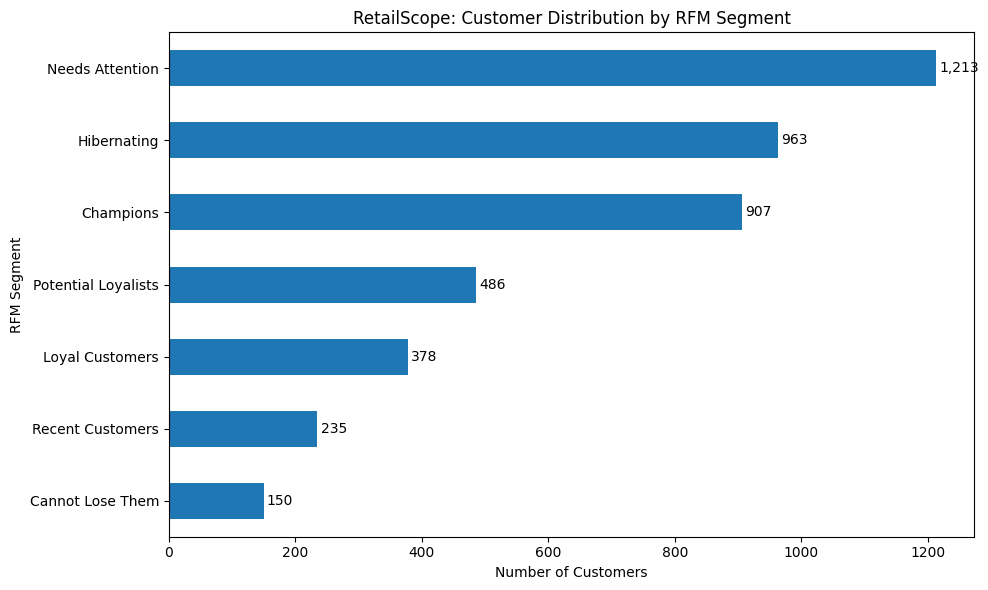

In [ ]:

import matplotlib.pyplot as plt

# Count customers in each adjusted RFM segment
segment_counts = (
    rfm_scored_adjusted["Segment"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))
ax = segment_counts.plot(kind="barh")

plt.title("RetailScope: Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")

for i, value in enumerate(segment_counts):
    ax.text(value + 5, i, f"{value:,}", va="center")

plt.tight_layout()
plt.show()


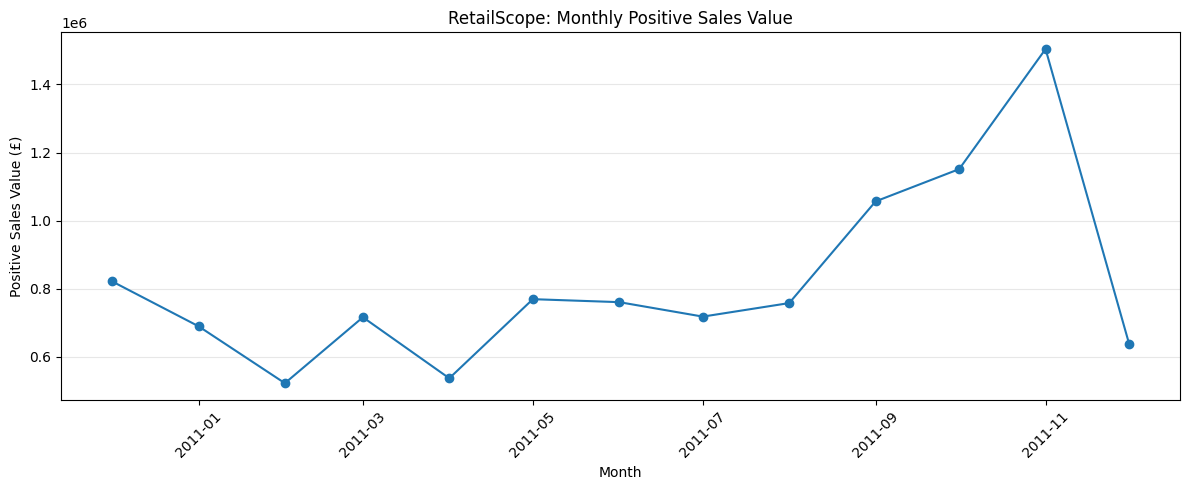

In [ ]:

monthly_sales = sales_df.copy()

monthly_sales["Month"] = (
    monthly_sales["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
)

monthly_sales_summary = (
    monthly_sales.groupby("Month")["LineValue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales_summary.index,
    monthly_sales_summary.values,
    marker="o"
)

plt.title("RetailScope: Monthly Positive Sales Value")
plt.xlabel("Month")
plt.ylabel("Positive Sales Value (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


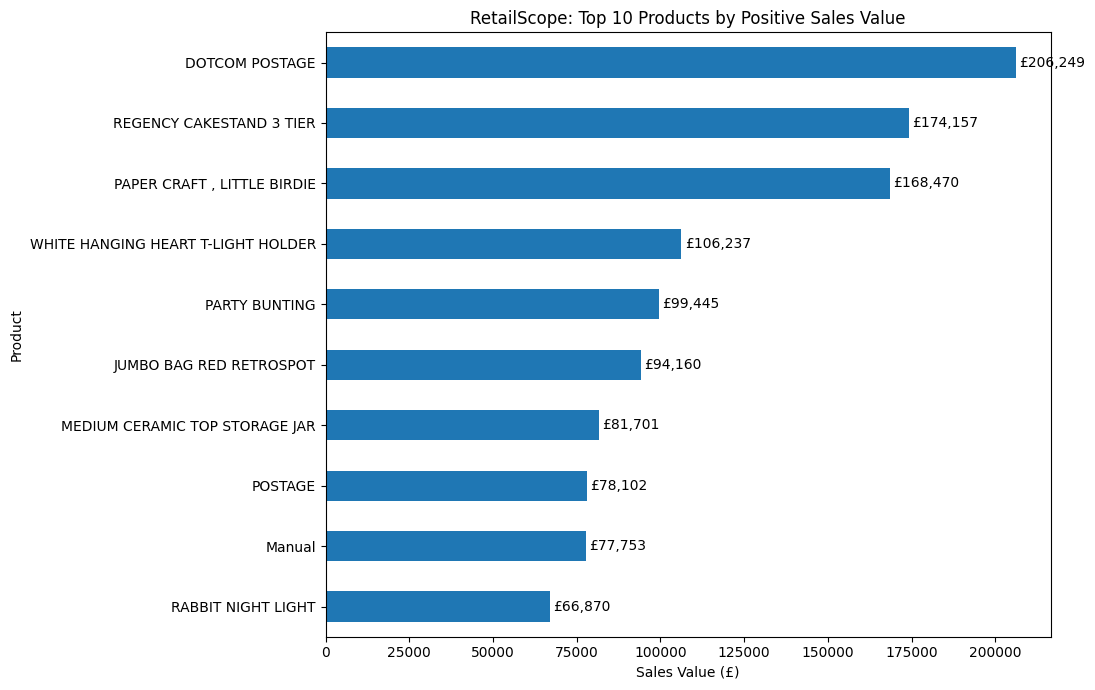

In [ ]:

import matplotlib.pyplot as plt

top_products = (
    sales_df.groupby("Description")["LineValue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 7))
ax = top_products.plot(kind="barh")

plt.title("RetailScope: Top 10 Products by Positive Sales Value")
plt.xlabel("Sales Value (£)")
plt.ylabel("Product")

for i, value in enumerate(top_products):
    ax.text(value + 1000, i, f"£{value:,.0f}", va="center")

plt.tight_layout()
plt.show()


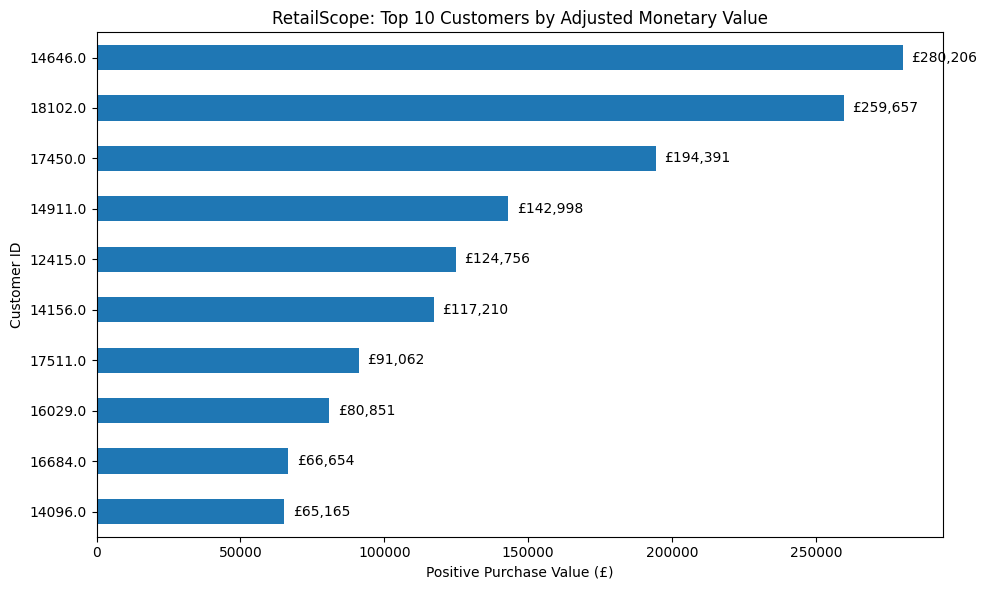

In [ ]:

top_customers = (
    rfm_adjusted["Monetary"]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

# Convert customer IDs to strings for clearer chart labels
top_customers.index = top_customers.index.astype(str)

plt.figure(figsize=(10, 6))
ax = top_customers.plot(kind="barh")

plt.title("RetailScope: Top 10 Customers by Adjusted Monetary Value")
plt.xlabel("Positive Purchase Value (£)")
plt.ylabel("Customer ID")

for i, value in enumerate(top_customers):
    ax.text(value + 3000, i, f"£{value:,.0f}", va="center")

plt.tight_layout()
plt.show()


In [ ]:

# RetailScope: Key Business Metrics

total_sales = sales_df["LineValue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
total_products = sales_df["StockCode"].nunique()
total_countries = sales_df["Country"].nunique()

# Country contribution
country_sales = sales_df.groupby("Country")["LineValue"].sum().sort_values(ascending=False)
top_country = country_sales.index[0]
top_country_sales = country_sales.iloc[0]
top_country_share = top_country_sales / total_sales * 100

# Monthly sales growth: compare August and November 2011
monthly_sales = sales_df.groupby(
    sales_df["InvoiceDate"].dt.to_period("M")
)["LineValue"].sum()

august_sales = monthly_sales.get(pd.Period("2011-08"), 0)
november_sales = monthly_sales.get(pd.Period("2011-11"), 0)
aug_to_nov_growth = (november_sales / august_sales - 1) * 100

# Customer metrics
customer_count = rfm_adjusted.shape[0]
average_customer_value = rfm_adjusted["Monetary"].mean()

segment_counts = rfm_scored_adjusted["Segment"].value_counts()
champions_count = segment_counts.get("Champions", 0)
hibernating_count = segment_counts.get("Hibernating", 0)
needs_attention_count = segment_counts.get("Needs Attention", 0)

print("===== RETAILSCOPE BUSINESS SUMMARY =====")
print(f"Positive sales value: £{total_sales:,.2f}")
print(f"Distinct invoices: {total_orders:,}")
print(f"Distinct products: {total_products:,}")
print(f"Countries served: {total_countries:,}")
print(f"Identified customers in adjusted RFM: {customer_count:,}")
print(f"Average adjusted monetary value per customer: £{average_customer_value:,.2f}")

print("\n===== SALES INSIGHTS =====")
print(f"Largest market: {top_country}")
print(f"Largest market sales value: £{top_country_sales:,.2f}")
print(f"Largest market share: {top_country_share:.2f}%")
print(f"August-to-November sales growth: {aug_to_nov_growth:.2f}%")

print("\n===== CUSTOMER INSIGHTS =====")
print(f"Champions: {champions_count:,}")
print(f"Hibernating: {hibernating_count:,}")
print(f"Needs Attention: {needs_attention_count:,}")


===== RETAILSCOPE BUSINESS SUMMARY =====
Positive sales value: £10,642,110.80
Distinct invoices: 19,960
Distinct products: 3,922
Countries served: 38
Identified customers in adjusted RFM: 4,332
Average adjusted monetary value per customer: £1,985.62

===== SALES INSIGHTS =====
Largest market: United Kingdom
Largest market sales value: £9,001,744.09
Largest market share: 84.59%
August-to-November sales growth: 98.44%

===== CUSTOMER INSIGHTS =====
Champions: 907
Hibernating: 963
Needs Attention: 1,213
